In [ ]:
# Documentação oficial das bibliotecas utilizadas:
# NumPy: biblioteca para computação numérica (média, variância, etc.)
# https://numpy.org/doc/
#
# Pandas: biblioteca para manipulação e análise de dados em DataFrames
# https://pandas.pydata.org/docs/
#
# SciPy (stats): módulo com funções estatísticas (ex: cálculo da moda)
# https://docs.scipy.org/doc/scipy/reference/stats.html

## **Problema Motivador**

Você é um Cientista de Dados em uma empresa de software e recebeu a seguinte tarefa:

Dois algoritmos distintos, denominados **Algoritmo A** e **Algoritmo B**, foram executados 60 vezes cada um, sob as mesmas condições experimentais, com o objetivo de avaliar seu desempenho em termos de tempo de execução.

Em cada execução, foi registrado o tempo de processamento, em milissegundos (ms). Os dados foram coletados, mas ainda não foram analisados.

Sua missão é elaborar um **relatório técnico**, no qual você deverá:
- Analisar o desempenho dos algoritmos;
- Compará-los de forma criteriosa;
- E, ao final, **recomendar qual deles deve ser utilizado em produção**, com base em argumentos bem fundamentados.

**Observação:**  
Os valores estão expressos com casas decimais, utilizando o ponto (.) como separador decimal.

💡 Reflita: quais informações você precisará extrair dos dados para tomar uma decisão segura?


### **Dados coletados**

**Algoritmo A – tempos de execução (ms):**

48.44, 47.77, 44.69, 43.47, 43.10, 41.53, 43.96, 38.67, 55.84, 51.04,  
39.38, 42.99, 42.67, 48.90, 44.58, 46.27, 44.86, 44.79, 51.84, 43.87,  
52.58, 37.26, 47.92, 45.62, 46.08, 46.90, 42.49, 43.33, 39.91, 39.64,  
46.52, 47.24, 45.27, 49.61, 55.25, 42.54, 33.45, 50.03, 41.45, 41.56,  
50.13, 43.58, 38.90, 45.91, 44.31, 45.03, 46.93, 43.15, 48.22, 43.90,  
46.66, 50.48, 47.18, 43.37, 50.74, 49.97, 47.74, 46.19, 41.86, 51.80.

---

**Algoritmo B – tempos de execução (ms):**

42.15, 41.88, 40.92, 39.77, 41.03, 38.95, 40.66, 37.84, 44.90, 43.21,  
38.45, 39.88, 40.11, 42.30, 41.52, 42.01, 41.33, 41.67, 43.95, 40.74,  
44.62, 36.88, 42.55, 41.89, 42.12, 42.85, 39.95, 40.61, 38.77, 38.99,  
42.44, 42.88, 41.73, 43.56, 45.10, 40.05, 35.92, 43.67, 39.74, 39.81,  
43.80, 40.92, 38.10, 41.85, 40.77, 41.63, 42.90, 40.48, 42.35, 40.96,  
42.61, 43.20, 42.70, 40.59, 43.88, 43.45, 42.91, 42.18, 40.22, 43.67.

## **Carregando os dados**

Nesta etapa, iremos carregar os dados coletados para iniciar a análise.

In [ ]:
# Importação das bibliotecas necessárias para análise de dados
# numpy: utilizado para cálculos numéricos (média, desvio padrão, variância, etc.)
# pandas: utilizado para organização e manipulação dos dados em estruturas como DataFrames
# scipy.stats: utilizado para cálculos estatísticos, como a moda

import numpy as np
import pandas as pd
from scipy import stats

algoritmo_A = np.array([
    48.44, 47.77, 44.69, 43.47, 43.10, 41.53, 43.96, 38.67, 55.84, 51.04,
    39.38, 42.99, 42.67, 48.90, 44.58, 46.27, 44.86, 44.79, 51.84, 43.87,
    52.58, 37.26, 47.92, 45.62, 46.08, 46.90, 42.49, 43.33, 39.91, 39.64,
    46.52, 47.24, 45.27, 49.61, 55.25, 42.54, 33.45, 50.03, 41.45, 41.56,
    50.13, 43.58, 38.90, 45.91, 44.31, 45.03, 46.93, 43.15, 48.22, 43.90,
    46.66, 50.48, 47.18, 43.37, 50.74, 49.97, 47.74, 46.19, 41.86, 51.80
])

algoritmo_B = np.array([
    42.15, 41.88, 40.92, 39.77, 41.03, 38.95, 40.66, 37.84, 44.90, 43.21,
    38.45, 39.88, 40.11, 42.30, 41.52, 42.01, 41.33, 41.67, 43.95, 40.74,
    44.62, 36.88, 42.55, 41.89, 42.12, 42.85, 39.95, 40.61, 38.77, 38.99,
    42.44, 42.88, 41.73, 43.56, 45.10, 40.05, 35.92, 43.67, 39.74, 39.81,
    43.80, 40.92, 38.10, 41.85, 40.77, 41.63, 42.90, 40.48, 42.35, 40.96,
    42.61, 43.20, 42.70, 40.59, 43.88, 43.45, 42.91, 42.18, 40.22, 43.67
])

df = pd.DataFrame({
    "Algoritmo_A": algoritmo_A,
    "Algoritmo_B": algoritmo_B
})

df.head()

,Algoritmo_A,Algoritmo_B
0,48.44,42.15
1,47.77,41.88
2,44.69,40.92
3,43.47,39.77
4,43.10,41.03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Algoritmo_A  60 non-null     float64
 1   Algoritmo_B  60 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


## **Análise exploratória de dados**

Nesta etapa, iremos explorar os dados para compreender suas principais características.

## **Medidas descritivas**

Nesta etapa, serão analisadas as principais medidas descritivas dos dados, incluindo:

- Média;
- Mediana;
- Moda;
- Desvio padrão;
- Variância;
- Amplitude.

In [ ]:
# Função para calcular medidas descritivas
def resumo(dados):
    return {
        "Média": np.mean(dados),
        "Mediana": np.median(dados),
        "Moda": stats.mode(dados, keepdims=True)[0][0],
        "Desvio Padrão": np.std(dados, ddof=1),
        "Variância": np.var(dados, ddof=1),
        "Amplitude": np.max(dados) - np.min(dados),
        "Coeficiente_Variação": np.std(dados, ddof=1) / np.mean(dados) * 100
    }

# Aplicando para cada algoritmo
resumo_A = resumo(df['Algoritmo_A'])
resumo_B = resumo(df['Algoritmo_B'])

# Convertendo para DataFrame
df_resumo = pd.DataFrame([resumo_A, resumo_B], index=["Algoritmo A", "Algoritmo B"])

df_resumo

,Média,Mediana,Moda,Desvio Padrão,Variância,Amplitude,Coeficiente_Variação
Algoritmo A,45.489333,45.15,33.45,4.299527,18.485932,22.39,9.451726
Algoritmo B,41.442833,41.70,40.92,1.941379,3.768953,9.18,4.684475


In [ ]:
df.describe()

,Algoritmo_A,Algoritmo_B
count,60.000000,60.000000
mean,45.489333,41.442833
std,4.299527,1.941379
min,33.450000,35.920000
25%,43.072500,40.192500
50%,45.150000,41.700000
75%,47.995000,42.857500
max,55.840000,45.100000


## **Análise visual dos dados**

/tmp/ipykernel_3958/2662869661.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["Algoritmo_A"], df["Algoritmo_B"]], labels=["Algoritmo A", "Algoritmo B"])


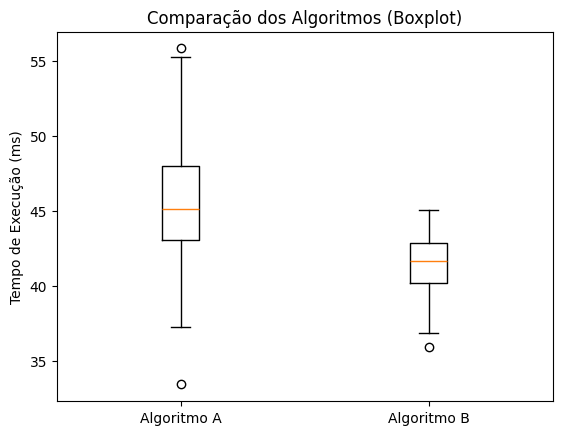

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# Boxplot comparando os dois algoritmos
plt.boxplot([df["Algoritmo_A"], df["Algoritmo_B"]], labels=["Algoritmo A", "Algoritmo B"])

plt.title("Comparação dos Algoritmos (Boxplot)")
plt.ylabel("Tempo de Execução (ms)")

plt.show()

02- Foi retirada uma amostra de galões de tinta produzida por uma fábrica, e registradas as seguintes medidas para o
tempo de secagem, em horas, de certa marca de tinta látex:

3,4 ; 2,5 ; 4,8 ; 2,9 ; 3,6 ; 2,8 ; 3,3 ; 5,6 ; 3,7 ; 2,8 ; 4,4 ; 4,0 ;5,2 ; 3,0 ; 4,8.

a) Qual é o tamanho da amostra acima?

b) Qual a variável (dado) que está sendo investigado? E qual é o tipo de dado em estudo?

c) Determine a média, a mediana e a moda para essa amostra.

d) Determine o mínimo, máximo, a variância, desvio-padrão e Coeficiente de variação (%).

In [ ]:
Dados01 = np.array([
    3.4, 2.5, 4.8, 2.9, 3.6, 2.8, 3.3, 5.6, 3.7, 2.8, 4.4, 4.0, 5.2 , 3.0 , 4.8
])


In [ ]:
Dados = pd.DataFrame({
    "Dados01": Dados01
})


In [ ]:
Dados

,Dados01
0,3.4
1,2.5
2,4.8
3,2.9
4,3.6
5,2.8
6,3.3
7,5.6
8,3.7
9,2.8


In [ ]:
resumo_Dados01= resumo(Dados['Dados01'])
df_resumo_Dados01 = pd.DataFrame([resumo_Dados01], index=["Dados01"])
df_resumo_Dados01

,Média,Mediana,Moda,Desvio Padrão,Variância,Amplitude,Coeficiente_Variação
Dados01,3.786667,3.6,2.8,0.97091,0.942667,3.1,25.640235


In [ ]:
Dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Dados01  15 non-null     float64
dtypes: float64(1)
memory usage: 252.0 bytes


In [ ]:
Dados.describe()

,Dados01
count,15.000000
mean,3.786667
std,0.970910
min,2.500000
25%,2.950000
50%,3.600000
75%,4.600000
max,5.600000


/tmp/ipykernel_3958/789673542.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([Dados['Dados01']], labels=["Galões"])


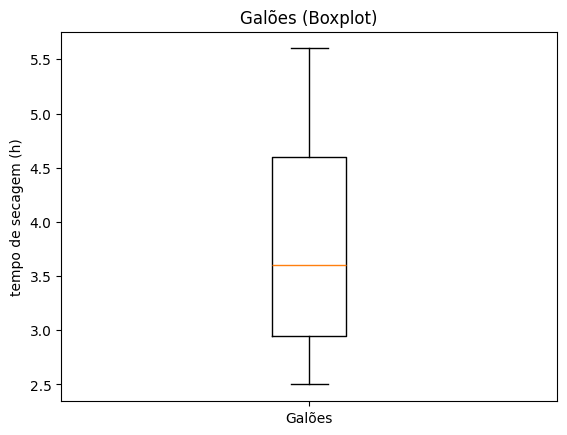

In [ ]:
import matplotlib.pyplot as plt

plt.figure()


plt.boxplot([Dados['Dados01']], labels=["Galões"])

plt.title("Galões (Boxplot)")
plt.ylabel("tempo de secagem (h)")

plt.show()

03- A quantidade de radiação recebida em uma estufa tem importante papel na determinação da taxa de fotossíntese.
As observações a seguir, sobre radiação solar, foram lidas de um gráfico no artigo “Radiation Components over Bare
and Planted Soils in a Greenhouse” (Solar Energy, 1990, p. 1011-1016):

6,3 ; 6,4 ; 7,7 ; 8,4 ; 8,5 ; 8,8 ; 8,9 ; 9,0 ; 9,1 ; 10,0 ; 10,1 ; 10,2 ; 10,6 ; 10,6;
10,7 ; 10,7 ; 10,8 ; 10,9 ; 11,1 ; 11,2 ; 11,2 ; 11,4 ; 11,9 ; 11,9 ; 12,2 ; 13,1

In [ ]:
radiacao = np.array([
    6.3 , 6.4 , 7.7 , 8.4 , 8.5 , 8.8 , 8.9 , 9.0 , 9.1 , 10.0 , 10.1 , 10.2 , 10.6 , 10.6,
10.7 , 10.7 , 10.8 , 10.9 , 11.1 , 11.2 , 11.2 , 11.4 , 11.9 , 11.9 , 12.2 , 13.1
])

In [ ]:
raio = pd.DataFrame({
    "Radiacao": radiacao,

})

raio.head()

,Radiacao
0,6.3
1,6.4
2,7.7
3,8.4
4,8.5


In [ ]:
raio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Radiacao  26 non-null     float64
dtypes: float64(1)
memory usage: 340.0 bytes


In [ ]:
raio.describe()

,Radiacao
count,26.000000
mean,10.065385
std,1.697278
min,6.300000
25%,8.925000
50%,10.600000
75%,11.175000
max,13.100000


In [ ]:
resumo_raio = resumo(raio['Radiacao'])
df_resumo_raio = pd.DataFrame([resumo_raio], index=["Radiacao"])
df_resumo_raio


,Média,Mediana,Moda,Desvio Padrão,Variância,Amplitude,Coeficiente_Variação
Radiacao,10.065385,10.6,10.6,1.697278,2.880754,6.8,16.862529


/tmp/ipykernel_3958/3125394884.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([raio['Radiacao']], labels=["Radiação Solar"])


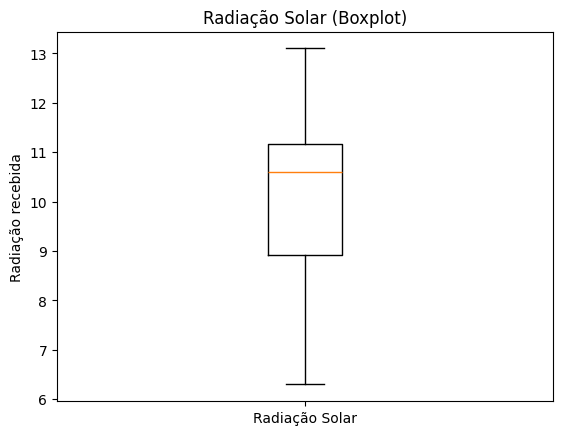

In [ ]:
plt.figure()


plt.boxplot([raio['Radiacao']], labels=["Radiação Solar"])

plt.title("Radiação Solar (Boxplot)")
plt.ylabel("Radiação recebida")

plt.show()

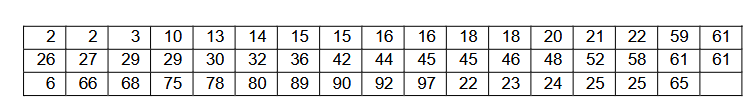

05- Para facilitar um projeto de ampliação da rede de esgoto de uma certa região de uma cidade, as autoridades
tomaram uma amostra de tamanho 50, dos 270 quarteirões que compõem a região, e foram encontrados os seguintes
números de casas por quarteirão:

2 2 3 10 13 14 15 15 16 16 18 18 20 21 22 59 61
26 27 29 29 30 32 36 42 44 45 45 46 48 52 58 61 61
6 66 68 75 78 80 89 90 92 97 22 23 24 25 25 65

a) Determine uma medida de posição central, para representar o número de casas/quarteirão dessa região, e
uma medida de dispersão que você acha mais adequada para representar esses dados.

b) Uma outra região apresentou um CV(%)=47,3% para o número médio de casas/quarteirão. Em qual das duas
regiões observa-se uma homogeneidade maior de resultados? Justifique

In [ ]:
casas_quarteirao = np.array([
    2, 2, 3, 6, 10, 13, 14, 15, 15, 16,
    16, 18, 18, 20, 21, 22, 22, 23, 24, 25,
    25, 26, 27, 29, 29, 30, 32, 36, 42, 44,
    45, 45, 46, 48, 52, 58, 59, 61, 61, 61,
    65, 66, 68, 75, 78, 80, 89, 90, 92, 97
])

In [ ]:
Casas = pd.DataFrame({
    "Casas": casas_quarteirao

})

Casas.head()

,Casas
0,2
1,2
2,3
3,6
4,10


In [ ]:
resumo_raio = resumo(raio['Radiacao'])
df_resumo_raio = pd.DataFrame([resumo_raio], index=["Radiacao"])
df_resumo_raio

In [ ]:
resumo_casas = resumo(Casas['Casas'])
df_casas= pd.DataFrame([resumo_casas], index=["casas_quarteirao"])
df_casas

,Média,Mediana,Moda,Desvio Padrão,Variância,Amplitude,Coeficiente_Variação
casas_quarteirao,39.22,29.5,61,26.255643,689.358776,95,66.944525
